Name - Sneha Arora <br>
Candidate Exercise - Scotiabank

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from datetime import date,time
import holidays
from networkdays import networkdays
from copy import deepcopy
from business_duration import businessDuration
import holidays as pyholidays
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
#load dataset files in dataframes

data_details = pd.read_excel('Mock Data.xlsx',sheet_name='Details')
data_cases = pd.read_excel('Mock Data.xlsx',sheet_name='Cases')
data_clients = pd.read_excel('Mock Data.xlsx',sheet_name='Clients')
data_details = pd.read_excel('Mock Data.xlsx',sheet_name='Details')
data_notification = pd.read_excel('Mock Data.xlsx',sheet_name='Notifications')
data_transits = pd.read_excel('Mock Data.xlsx',sheet_name='Transits')

In [3]:
data_details.head()

,Transit,Application Date,Closing Date,Case ID
0,240.0,2017-06-08,2017-07-11,PR-5697
1,240.0,2017-06-09,2017-09-25,PR-10106
2,240.0,2017-05-01,2017-07-31,PR-5142
3,240.0,2017-06-16,2017-08-10,PR-6044
4,240.0,2017-07-19,2017-08-29,PR-8966


In [4]:
#convert Region, district, branch to uppercase
data_transits['Region'] = data_transits['Region'].str.upper()
data_transits['District'] = data_transits['District'].str.upper()
data_transits['Branch'] = data_transits['Branch'].str.upper()

#renaming data_cases columns
data_cases= data_cases.rename(columns={'Create Time':'Cases Create Time','Resolved Time':'Cases Resolved Time'})

data_details['Application Date'] = pd.to_datetime(data_details['Application Date']) + pd.Timedelta('00:00:01')
data_details['Closing Date'] = pd.to_datetime(data_details['Closing Date']) + pd.Timedelta('00:00:01')

#read dataframe notification
data_details.head()

,Transit,Application Date,Closing Date,Case ID
0,240.0,2017-06-08 00:00:01,2017-07-11 00:00:01,PR-5697
1,240.0,2017-06-09 00:00:01,2017-09-25 00:00:01,PR-10106
2,240.0,2017-05-01 00:00:01,2017-07-31 00:00:01,PR-5142
3,240.0,2017-06-16 00:00:01,2017-08-10 00:00:01,PR-6044
4,240.0,2017-07-19 00:00:01,2017-08-29 00:00:01,PR-8966


In [5]:
#check NA and drop NA

print("Check NA in entire CASES dataframe : ", data_cases.isnull().values.any())
print("Check NA in entire DETAILS dataframe : ",data_details.isnull().values.any())
print("Check NA in entire TRANSITS dataframe : ",data_transits.isnull().values.any())
print("Check NA in entire NOTIFICATION dataframe : ",data_notification.isnull().values.any())
print("Check NA in entire CLIENTS dataframe : ",data_clients.isnull().values.any())

#Drop NA from the tables showing TRUE from above.
# data_transits = data_transits.dropna()
# data_clients = data_clients.dropna()

Check NA in entire CASES dataframe :  False
Check NA in entire DETAILS dataframe :  True
Check NA in entire TRANSITS dataframe :  False
Check NA in entire NOTIFICATION dataframe :  False
Check NA in entire CLIENTS dataframe :  True


In [6]:
#Join tables
data_cases_noti = data_cases.merge(data_notification, how='left', left_on='Case ID', right_on='Case ID')
data_cases_noti_detail = data_cases_noti.merge(data_details, how='left', left_on='Case ID', right_on='Case ID')
data_cases_noti_detail_transits = data_cases_noti_detail.merge(data_transits, how='left', left_on='Transit', right_on='Transit')

In [7]:
data_cases_noti_detail_transits.head()

,Case ID,Client ID,Cases Create Time,Cases Resolved Time,Notification ID,Description,Create Time,Resolved Time,Transit,Application Date,Closing Date,Region,District,Branch
0,PR-15932,CL-000001,2017-10-26 14:31:54,2017-11-01 15:04:27,N-110985,First Submit,2017-10-26 14:31:54,2017-10-27 11:11:49,2931.0,2017-08-31 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,OTTAWA CENTRE & GATINEAU,"PLAZA GLENWOOD, GATINEAU, QUEBEC"
1,PR-15932,CL-000001,2017-10-26 14:31:54,2017-11-01 15:04:27,N-114696,Resubmit,2017-11-01 10:00:30,2017-11-01 15:04:27,2931.0,2017-08-31 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,OTTAWA CENTRE & GATINEAU,"PLAZA GLENWOOD, GATINEAU, QUEBEC"
2,PR-16350,CL-000002,2017-11-01 12:42:43,2017-11-01 15:20:57,N-114911,First Submit,2017-11-01 12:42:43,2017-11-01 15:20:57,90001.0,2017-09-26 00:00:01,2017-11-24 00:00:01,QUEBEC & EASTERN ON,MONTREAL CENTRE,SUCCURSALE PRINCIPALE DE MONTREAL
3,PR-16416,CL-000003,2017-11-01 17:06:31,2017-11-02 11:37:52,N-115231,First Submit,2017-11-01 17:06:31,2017-11-02 11:37:52,31591.0,2017-10-30 00:00:01,2017-12-07 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,SUCCURSALE REGIONALE LAVAL/LAVAL MAIN
4,PR-16548,CL-000004,2017-11-02 16:25:34,2017-11-06 09:09:51,N-116013,First Submit,2017-11-02 16:25:34,2017-11-03 13:55:45,50641.0,2017-10-24 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,QUARTIER LAVAL


In [8]:
#ontario public holidays calculated using holiday function in python, province for Canada = ON by default

import holidays

canada_holidays = holidays.Canada()

ontario_public_holidays = [holiday[0] for holiday in holidays.Canada(years = [2017,2018,2019]).items()]
# ontario_public_holidays

In [9]:
#Calculations

def calculate_network_days(row,start_date_col,end_date_col):

    biz_open_time = time(0,0,0)
    biz_close_time = time(23,59,59)
    unit_hour='day'

    if pd.isnull(row[start_date_col]) != True and pd.isnull(row[end_date_col])!= True:
        days = businessDuration(startdate=row[start_date_col],enddate=row[end_date_col],starttime=biz_open_time,endtime=biz_close_time,holidaylist=ontario_public_holidays,unit=unit_hour)
        return days
    else:
        return np.nan

    
#Notification Time:# of business days between ‘Notifications’[Create Time] and ‘Notifications’[Resolved Time]
data_cases_noti_detail_transits['Notification Time'] = data_cases_noti_detail_transits.apply(calculate_network_days, axis=1, start_date_col = 'Create Time', end_date_col = 'Resolved Time')

# Case Time: # of business days between ‘Cases’[Create Time] and ‘Cases’[Resolved Time]
data_cases_noti_detail_transits['Case Time'] = data_cases_noti_detail_transits.apply(calculate_network_days, axis=1, start_date_col = 'Cases Create Time', end_date_col = 'Cases Resolved Time')

#Time to Pre-Fund Decisions: # of business days between ‘Details’[Application Date] and ‘Cases’[Resolved Time]
data_cases_noti_detail_transits['Time to Pre-Fund Decisions'] = data_cases_noti_detail_transits.apply(calculate_network_days, axis=1, start_date_col = 'Application Date', end_date_col = 'Cases Resolved Time')

# add column First Time Right(Y/N) for every case id, "Y" if they have only one notification id, else "N"
data_cases_noti_detail_transits['First Time Right(Y/N)'] = data_cases_noti_detail_transits.groupby('Case ID')['Notification ID'].transform(lambda x: "Y" if x.nunique() == 1 else "N")

# Sum of all Notification Time for the associated Case
df_sum_of_notificationtime = data_cases_noti_detail_transits.groupby('Case ID')['Notification Time'].sum().reset_index(name='Sum of Notification Time')

list_of_columns = ['Case ID','First Time Right(Y/N)','Cases Create Time','Cases Resolved Time','Application Date','Region','District','Branch','Case Time','Time to Pre-Fund Decisions']
df_not_first_time_right = df_sum_of_notificationtime.merge(data_cases_noti_detail_transits[list_of_columns], how='left', left_on='Case ID', right_on='Case ID')

# Not First Time Right Branch Time: (Case Time) – (SUM of all Notification Time for the associated Case)
#Branch Making Revision Time
df_not_first_time_right['Branch Time'] = df_not_first_time_right['Case Time'] - df_not_first_time_right['Sum of Notification Time']

df_not_first_time_right.head() # data on case level
data_cases_noti_detail_transits.head() # data on notification level

,Case ID,Client ID,Cases Create Time,Cases Resolved Time,Notification ID,Description,Create Time,Resolved Time,Transit,Application Date,Closing Date,Region,District,Branch,Notification Time,Case Time,Time to Pre-Fund Decisions,First Time Right(Y/N)
0,PR-15932,CL-000001,2017-10-26 14:31:54,2017-11-01 15:04:27,N-110985,First Submit,2017-10-26 14:31:54,2017-10-27 11:11:49,2931.0,2017-08-31 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,OTTAWA CENTRE & GATINEAU,"PLAZA GLENWOOD, GATINEAU, QUEBEC",0.861053,4.022604,42.628079,N
1,PR-15932,CL-000001,2017-10-26 14:31:54,2017-11-01 15:04:27,N-114696,Resubmit,2017-11-01 10:00:30,2017-11-01 15:04:27,2931.0,2017-08-31 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,OTTAWA CENTRE & GATINEAU,"PLAZA GLENWOOD, GATINEAU, QUEBEC",0.211076,4.022604,42.628079,N
2,PR-16350,CL-000002,2017-11-01 12:42:43,2017-11-01 15:20:57,N-114911,First Submit,2017-11-01 12:42:43,2017-11-01 15:20:57,90001.0,2017-09-26 00:00:01,2017-11-24 00:00:01,QUEBEC & EASTERN ON,MONTREAL CENTRE,SUCCURSALE PRINCIPALE DE MONTREAL,0.109884,0.109884,25.639537,Y
3,PR-16416,CL-000003,2017-11-01 17:06:31,2017-11-02 11:37:52,N-115231,First Submit,2017-11-01 17:06:31,2017-11-02 11:37:52,31591.0,2017-10-30 00:00:01,2017-12-07 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,SUCCURSALE REGIONALE LAVAL/LAVAL MAIN,0.771771,0.771771,3.484618,Y
4,PR-16548,CL-000004,2017-11-02 16:25:34,2017-11-06 09:09:51,N-116013,First Submit,2017-11-02 16:25:34,2017-11-03 13:55:45,50641.0,2017-10-24 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,QUARTIER LAVAL,0.895961,1.697419,9.381829,N


In [10]:
df_not_first_time_right.head()

,Case ID,Sum of Notification Time,First Time Right(Y/N),Cases Create Time,Cases Resolved Time,Application Date,Region,District,Branch,Case Time,Time to Pre-Fund Decisions,Branch Time
0,PR-10000,1.102708,Y,2017-08-16 13:49:26,2017-08-17 16:17:20,2017-08-04 00:00:01,ONTARIO,BARRIE & AREA,MAPLEVIEW DRIVE AND HIGHWAY 400,1.102708,8.678692,0.000000
1,PR-10001,1.097558,Y,2017-08-16 13:52:42,2017-08-17 16:13:11,2017-08-03 00:00:01,ONTARIO,WATERLOO REGION,"HIGHLAND PARK, KITCHENER, ONT.,",1.097558,9.675810,0.000000
2,PR-10002,1.113356,Y,2017-08-16 13:59:54,2017-08-17 16:43:08,NaT,NaN,NaN,NaN,1.113356,NaN,0.000000
3,PR-10003,1.133426,N,2017-08-16 14:04:48,2017-08-17 17:44:12,2017-08-01 00:00:01,ONTARIO,SOUTHWEST ONTARIO,"NORTHGATE SHOPPING CENTRE, SARNIA, ONT.",1.152361,11.739016,0.018935
4,PR-10003,1.133426,N,2017-08-16 14:04:48,2017-08-17 17:44:12,2017-08-01 00:00:01,ONTARIO,SOUTHWEST ONTARIO,"NORTHGATE SHOPPING CENTRE, SARNIA, ONT.",1.152361,11.739016,0.018935


____

**1. Showcase which Regions and Districts were the worst performing when it comes to first time right.**

In [11]:
#Region

FirstTimeRIghtregion = data_cases_noti_detail_transits.groupby('Region')['First Time Right(Y/N)'].value_counts().reset_index(name='Count of Y/N')
Sum_Region = FirstTimeRIghtregion.groupby('Region')['Count of Y/N'].sum().reset_index(name = 'Total of Y and N')

percentagereg = FirstTimeRIghtregion.merge(Sum_Region, how='left', left_on='Region', right_on='Region')
percentagereg['Percentage (FTR/Total)'] = percentagereg['Count of Y/N']/percentagereg['Total of Y and N']*100
percentagereg = percentagereg.sort_values(by=['First Time Right(Y/N)','Percentage (FTR/Total)'],ascending=[True, False])
percentagereg

,Region,First Time Right(Y/N),Count of Y/N,Total of Y and N,Percentage (FTR/Total)
6,PRAIRIE,N,4712,6746,69.848799
2,BC & YUKON,N,3015,4378,68.867063
0,ATLANTIC,N,2735,4061,67.347944
8,QUEBEC & EASTERN ON,N,3253,4939,65.863535
10,TORONTO,N,7660,12155,63.019334
4,ONTARIO,N,8342,13357,62.454144
5,ONTARIO,Y,5015,13357,37.545856
11,TORONTO,Y,4495,12155,36.980666
9,QUEBEC & EASTERN ON,Y,1686,4939,34.136465
1,ATLANTIC,Y,1326,4061,32.652056


The above regions are arranged in the descending order of Worst performance using Percentage.

In [13]:
#District

FirstTimeRIghtdis = data_cases_noti_detail_transits.groupby('District')['First Time Right(Y/N)'].value_counts().reset_index(name='Count of Y/N')
Sum_District = FirstTimeRIghtdis.groupby('District')['Count of Y/N'].sum().reset_index(name = 'Total of Y and N')

percentagedis = FirstTimeRIghtdis.merge(Sum_District, how='left', left_on='District', right_on='District')
percentagedis['Percentage (FTR/Total)'] = percentagedis['Count of Y/N']/percentagedis['Total of Y and N']*100
percentagedis = percentagedis.sort_values(by=['First Time Right(Y/N)','Percentage (FTR/Total)'],ascending=[True, False])
percentagedis = percentagedis.merge(data_transits[['Region','District']], how='inner', left_on='District', right_on='District')
percentagedis.drop_duplicates(inplace=True)
percentagedis

,District,First Time Right(Y/N),Count of Y/N,Total of Y and N,Percentage (FTR/Total),Region
0,SOUTHSHORE & QUEBEC CITY,N,32,41,78.048780,QUEBEC & EASTERN ON
2,SOUTHSHORE & QUEBEC CITY,Y,9,41,21.951220,QUEBEC & EASTERN ON
4,ALBERTA SOUTH,N,465,621,74.879227,PRAIRIE
22,ALBERTA SOUTH,Y,156,621,25.120773,PRAIRIE
40,SOUTHWEST NOVA SCOTIA,N,246,331,74.320242,ATLANTIC
...,...,...,...,...,...,...
1811,DOWNTOWN & NORTH VANCOUVER,Y,171,416,41.105769,BC & YUKON
1828,WATERLOO REGION,N,574,975,58.871795,ONTARIO
1844,WATERLOO REGION,Y,401,975,41.128205,ONTARIO
1860,LONDON & AREA,N,667,1203,55.444722,ONTARIO


The above Districts are arranged in the descending order of worst performance. The regions corresponding to the respective districts are shown as well.

Results are shown in the form of visualisation below.

In [14]:
#Region
FTR_Y = percentagereg[percentagereg['First Time Right(Y/N)'] == 'Y']
FTR_N = percentagereg[percentagereg['First Time Right(Y/N)'] == 'N']

fig1 = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.15,
                    subplot_titles=['Worst Performing REGIONS by Percentage'])

fig1.add_trace(go.Bar(x=FTR_N['Region'], y=FTR_N['Percentage (FTR/Total)'],
                     name='Not First Time Right (higher % is worse)', marker_color='#F25E3F'),
              row=1, col=1)

fig1.add_trace(go.Bar(x=FTR_Y['Region'], y=FTR_Y['Percentage (FTR/Total)'],
                     name='First Time Right (lower % is better)', marker_color='green'),
              row=1, col=1)

fig1.update_traces(texttemplate='%{y:.2f}', textposition='auto', textfont_color='white')

fig1.update_xaxes(title_text='Region', row=1, col=1)
fig1.update_yaxes(title_text='Percentage of FTR/Total', row=1, col=1)
fig1.update_layout(barmode='group', height=450, width=1200, title_text='Bar Chart for Worst Performing Regions')
fig1.show()

#District
FTR_Y_d = percentagedis[percentagedis['First Time Right(Y/N)'] == 'Y'].head()
FTR_N_d = percentagedis[percentagedis['First Time Right(Y/N)'] == 'N'].head()

fig2 = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.15,
                    subplot_titles=[ 'Top 5 Worst Performing DISTRICTS by Percentage'])

fig2.add_trace(go.Bar(x=FTR_N_d['District'], y=FTR_N_d['Percentage (FTR/Total)'],
                     name='Not First Time Right (higher % is worse)', marker_color='#F25E3F'),
              row=1, col=1)

fig2.add_trace(go.Bar(x=FTR_Y_d['District'], y=FTR_Y_d['Percentage (FTR/Total)'],
                     name='First Time Right (lower % is better)', marker_color='green'),
              row=1, col=1)

fig2.update_traces(texttemplate='%{y:.2f}', textposition='auto', textfont_color='white')

fig2.update_xaxes(title_text='District', row=1, col=1)
fig2.update_yaxes(title_text='Percentage of FTR/Total', row=1, col=1)
fig2.update_layout(barmode='group', height=450, width=1200, title_text='Worst Performing DISTRICTS by Percentage')
fig2.show()


According to the count of first time right for all the cases per region, PRAIRIE region is the worst performing with percentage = 69.84%, followed by BC & YUKON with percentage = 68.86% <br>
Whereas for Districts, the worst performing district is SOUTHSHORE & QUEBEC CITY of region - Quebec & Eastern ON as percentage = 78.04% followed by ALBERTA SOUTH of region - PRAIRIE giving percentage = 74.87%.

___

2. What is the impact on ‘Time to Pre-Fund Decision’ and ‘Case Time’ when a case is not first time right?

In [15]:
#pre-processing

df_impact = deepcopy(data_cases_noti_detail_transits.drop_duplicates('Case ID')).reset_index(drop=True)
df_impact.drop(columns=['Notification ID','Notification Time'], inplace=True)
df_impact.head()

,Case ID,Client ID,Cases Create Time,Cases Resolved Time,Description,Create Time,Resolved Time,Transit,Application Date,Closing Date,Region,District,Branch,Case Time,Time to Pre-Fund Decisions,First Time Right(Y/N)
0,PR-15932,CL-000001,2017-10-26 14:31:54,2017-11-01 15:04:27,First Submit,2017-10-26 14:31:54,2017-10-27 11:11:49,2931.0,2017-08-31 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,OTTAWA CENTRE & GATINEAU,"PLAZA GLENWOOD, GATINEAU, QUEBEC",4.022604,42.628079,N
1,PR-16350,CL-000002,2017-11-01 12:42:43,2017-11-01 15:20:57,First Submit,2017-11-01 12:42:43,2017-11-01 15:20:57,90001.0,2017-09-26 00:00:01,2017-11-24 00:00:01,QUEBEC & EASTERN ON,MONTREAL CENTRE,SUCCURSALE PRINCIPALE DE MONTREAL,0.109884,25.639537,Y
2,PR-16416,CL-000003,2017-11-01 17:06:31,2017-11-02 11:37:52,First Submit,2017-11-01 17:06:31,2017-11-02 11:37:52,31591.0,2017-10-30 00:00:01,2017-12-07 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,SUCCURSALE REGIONALE LAVAL/LAVAL MAIN,0.771771,3.484618,Y
3,PR-16548,CL-000004,2017-11-02 16:25:34,2017-11-06 09:09:51,First Submit,2017-11-02 16:25:34,2017-11-03 13:55:45,50641.0,2017-10-24 00:00:01,2017-11-15 00:00:01,QUEBEC & EASTERN ON,LAVAL & NORTH,QUARTIER LAVAL,1.697419,9.381829,N
4,PR-16585,CL-000005,2017-11-03 08:28:38,2017-11-03 14:17:33,First Submit,2017-11-03 08:28:38,2017-11-03 14:17:33,10041.0,2017-09-14 00:00:01,2017-11-28 00:00:01,QUEBEC & EASTERN ON,SOUTH SHORE & QUEBEC CITY,"PLACE QUEBEC, QUEBEC",0.242303,35.595509,Y


In [16]:
#Time to Pre-Fund Decision impact on 'Case not first time right'
PreFund_Avg = df_impact.groupby('First Time Right(Y/N)')['Time to Pre-Fund Decisions'].mean().reset_index(name = 'PF Average days')
PreFund_Median = df_impact.groupby('First Time Right(Y/N)')['Time to Pre-Fund Decisions'].median().reset_index(name = 'PF Median days')
display(PreFund_Avg)
display(PreFund_Median)

#Case Time impact on 'Case not first time right'
CaseTime_Avg = df_impact.groupby('First Time Right(Y/N)')['Case Time'].mean().reset_index(name = 'Case Average days')
CaseTime_Median = df_impact.groupby('First Time Right(Y/N)')['Case Time'].median().reset_index(name = 'Case Median days')
display(CaseTime_Avg)
display(CaseTime_Median)

,First Time Right(Y/N),PF Average days
0,N,30.587219
1,Y,25.290505


,First Time Right(Y/N),PF Median days
0,N,23.513171
1,Y,18.387193


,First Time Right(Y/N),Case Average days
0,N,4.585022
1,Y,0.819665


,First Time Right(Y/N),Case Median days
0,N,2.794664
1,Y,0.850203


In [17]:
def calculate_impact(temp_df, col_name):
    mask_N = temp_df["First Time Right(Y/N)"] == "N"
    mask_Y = temp_df["First Time Right(Y/N)"] == "Y"
    impact_percentage = ((float(temp_df.loc[np.where(mask_N)[0][0], col_name]) - float(temp_df.loc[np.where(mask_Y)[0][0], col_name]))/float(temp_df.loc[np.where(mask_Y)[0][0], col_name]))*100
    return impact_percentage

In [18]:
print('Pre-Fund Average Increase for Not First time right : ',calculate_impact(PreFund_Avg,'PF Average days'),'%')
print('Pre-Fund Median Increase for Not First time right : ',calculate_impact(PreFund_Median,'PF Median days'),'%')
print('Case Time Average Increase for Not First time right : ',calculate_impact(CaseTime_Avg,'Case Average days'),'%')
print('Case Time Median Increase for Not First time right : ',calculate_impact(CaseTime_Median,'Case Median days'),'%')

Pre-Fund Average Increase for Not First time right :  20.943488249660888 %
Pre-Fund Median Increase for Not First time right :  27.877979685312127 %
Case Time Average Increase for Not First time right :  459.3777757864763 %
Case Time Median Increase for Not First time right :  228.7057141884763 %


Please refer to the below data visualisation in the form of graph to view the results.

In [19]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Average Time to Pre-Fund Decisions (days) - Not First time right", "Average Case Time (days) - Not First time right"])

fig1 = px.bar(PreFund_Avg, x='First Time Right(Y/N)', y='PF Average days')

fig2 = px.bar(CaseTime_Avg, x='First Time Right(Y/N)', y='Case Average days')

fig1.update_traces(texttemplate='%{y:.2f}', textposition='auto')
fig2.update_traces(texttemplate='%{y:.2f}', textposition='auto')

fig.add_trace(go.Figure(fig1).data[0], row=1, col=1)
fig.add_trace(go.Figure(fig2).data[0], row=1, col=2)

fig.update_layout(height=400, width=1200, showlegend=False, xaxis_title = 'First Time Right(Y/N)', yaxis_title = 'Average Days')

fig.show()

****Impact****
Using 'Average' as a metric<br>
The  Average Time taken for Pre-Fund decisions for the cases which are first time not right is 20% more than for those cases which are first time right according to above result.<br> 
However for the Average of Case Time, for not first time right cases, its 459% more than the ones which are first time right.
<br><br>
Using 'Median' as a metric <br>
For the Median time taken for Pre fund decisions which are not first time right is 27.8% more than the ones which are first time right.<br>
Whereas, the median of Case TIme, for not first time right cases is 228.7% (4:2), more than the ones which are first time right.
<br><br>
Average # Notification/Case is in the range of 1.6 and 1.2.

____

3. What is the average number of notifications associated with each case and are there any trends positive or negative?

In [21]:
data_cases_noti_detail_transits['Notification Create Month'] = data_cases_noti_detail_transits['Create Time'].dt.month_name()
data_cases_noti_detail_transits['Notification Create Year'] =  data_cases_noti_detail_transits['Create Time'].dt.year
data_cases_noti_detail_transits['Notification Create Days'] =  data_cases_noti_detail_transits['Create Time'].dt.day

#over month

year2017 = data_cases_noti_detail_transits.loc[data_cases_noti_detail_transits['Notification Create Year']==2017]
year2018 = data_cases_noti_detail_transits.loc[data_cases_noti_detail_transits['Notification Create Year']==2018]
Avg_noti_month2017 = year2017.groupby('Notification Create Month')['Notification ID'].count().reset_index(name = 'Monthly Count of Notification IDs-2017')
Avg_noti_month2018 = year2018.groupby('Notification Create Month')['Notification ID'].count().reset_index(name = 'Monthly Count of Notification IDs-2018')
# Avg_noti_month2017['Case Count 2017'] = year2017.groupby('Notification Create Month')['Case ID'].transform('nunique')
Avg_case_month2017 = year2017.groupby('Notification Create Month')['Case ID'].nunique().reset_index(name = 'Monthly Count of Case IDs-2017')
Avg_case_month2018 = year2018.groupby('Notification Create Month')['Case ID'].nunique().reset_index(name = 'Monthly Count of Case IDs-2018')

months_dict = {'January' : 1, 'February' : 2, 'March' : 3, 'April' : 4, 'May' : 5, 'June' : 6, 'July' : 7, 'August' : 8, 'September' : 9, 'October' :10, 'November' : 11, 'December' : 12}

avg_notipercase2017 = Avg_noti_month2017.merge(Avg_case_month2017, how = 'inner', left_on='Notification Create Month', right_on='Notification Create Month')
avg_notipercase2017['Average CountNoti/CountCase 2017'] = avg_notipercase2017['Monthly Count of Notification IDs-2017']/avg_notipercase2017['Monthly Count of Case IDs-2017']
avg_notipercase2018 = Avg_noti_month2018.merge(Avg_case_month2018, how = 'inner', left_on='Notification Create Month', right_on='Notification Create Month')
avg_notipercase2018['Average CountNoti/CountCase 2018'] = avg_notipercase2018['Monthly Count of Notification IDs-2018']/avg_notipercase2018['Monthly Count of Case IDs-2018']
avg_notipercase = avg_notipercase2017.merge(avg_notipercase2018[['Average CountNoti/CountCase 2018','Notification Create Month']], how = 'outer', left_on='Notification Create Month', right_on='Notification Create Month')
avg_notipercase.drop(columns=['Monthly Count of Notification IDs-2017','Monthly Count of Case IDs-2017'], inplace=True)
avg_notipercase = avg_notipercase.sort_values('Notification Create Month', key = lambda x : x.apply (lambda x : months_dict[x]))
display(avg_notipercase)

#over days

avg_noti_days = data_cases_noti_detail_transits.groupby('Notification Create Days')['Notification ID'].count().reset_index(name = 'Days count of Notification IDs')
avg_case_days = data_cases_noti_detail_transits.groupby('Notification Create Days')['Case ID'].nunique().reset_index(name = 'Days count of Case IDs')
avg_notipercase_days = avg_noti_days.merge(avg_case_days, how = 'inner', left_on='Notification Create Days', right_on='Notification Create Days')
avg_notipercase_days['Average CountNoti/CountCase'] = avg_notipercase_days['Days count of Notification IDs']/avg_notipercase_days['Days count of Case IDs']
display(avg_notipercase_days)

,Notification Create Month,Average CountNoti/CountCase 2017,Average CountNoti/CountCase 2018
10,January,NaN,1.595174
9,February,NaN,1.552600
11,March,NaN,1.527540
0,April,1.666667,1.573451
5,May,1.142857,1.547534
4,June,1.255814,1.579731
3,July,1.362470,1.589565
1,August,1.418100,NaN
8,September,1.393778,NaN
7,October,1.434416,NaN


,Notification Create Days,Days count of Notification IDs,Days count of Case IDs,Average CountNoti/CountCase
0,1,1254,1205,1.040664
1,2,1222,1170,1.044444
2,3,1223,1162,1.052496
3,4,1508,1419,1.062720
4,5,1582,1493,1.059612
5,6,1660,1570,1.057325
6,7,1421,1351,1.051813
7,8,1470,1400,1.050000
8,9,1365,1274,1.071429
9,10,1331,1271,1.047207


The above results show the average over months(separately for both years) and days of the month (aggregated over all months for both years).

Below Visualisation to show the results for average of notifications per case, for both years 2017 and 2018, added to the same graph. <br>
Please click on the legends to choose the trend line for 'Year' separately.

In [22]:
import plotly.express as px

fig = px.line(avg_notipercase, x='Notification Create Month', y=['Average CountNoti/CountCase 2017', 'Average CountNoti/CountCase 2018'],
              labels={'value': 'Average(Notification_Count/Case_Count)', 'variable': 'Year'},
              title='Average CountNoti/CountCase for 2017 and 2018')
fig.update_xaxes(title_text='Months')
fig.show()

Showing trend according to the days of the month.

In [23]:
fig = px.line(avg_notipercase_days, x='Notification Create Days', y=['Average CountNoti/CountCase'],
              labels={'value': 'Average(Notification_Count/Case_Count)', 'variable': 'Days'},
              title='Trend according to days')
fig.update_xaxes(title_text='Days of month')

fig.show()

The overall trend is rising from the month of May for both Years - 2017 and 2018. Year - 2018 shows more average than Year - 2017.
<br>
The trend when looked with respected to months, seems rising i.e. with the average number of notifications per case is rising.
<br>
When look through the days of the month, it seems to be higher in the beginning and end of the month, a sharp increase around 9th/10th day. Lower average in the middle of the month. This is aggregated for all the months (Jan-Dec) together for both years (2017-2018).

The overall trend shows positive i.e. more average number of notifications per case. 

____

4. When a case is not first time right, what is the percent of total case time spent with the branch making revisions vs. Pre-Fund working the notifications.

In [24]:
#Drop duplicate rows having same Case ID and calculating percentages for not first time right.

df_not_first_time_right.drop_duplicates('Case ID',inplace=True)
df_not_first_time_right['Branch Time % age'] = df_not_first_time_right['Branch Time']/(df_not_first_time_right['Case Time'])*100
df_not_first_time_right['Pre-Fund Working Noti % age'] = df_not_first_time_right['Sum of Notification Time']/(df_not_first_time_right['Case Time'])*100
df_not_first_time_right_no = df_not_first_time_right.loc[df_not_first_time_right['First Time Right(Y/N)']=='N']

In [25]:
#Aggregate on Region

region_percentage_branch = df_not_first_time_right_no.groupby('Region')['Branch Time % age'].mean().reset_index(name='Branch %age')
region_percentage_prefund = df_not_first_time_right_no.groupby('Region')['Pre-Fund Working Noti % age'].mean().reset_index(name='Pre-Fund working noti %age')
display(region_percentage_branch.sort_values(by = ['Branch %age'], ascending=False))
display(region_percentage_prefund.sort_values(by = ['Pre-Fund working noti %age'], ascending=False))

district_percentage_branch = df_not_first_time_right_no.groupby('District')['Branch Time % age'].mean().reset_index(name='Branch %age')
district_percentage_prefund = df_not_first_time_right_no.groupby('District')['Pre-Fund Working Noti % age'].mean().reset_index(name='Pre-Fund working noti %age')
print(district_percentage_branch.sort_values(by = ['Branch %age'], ascending=False).head())
print(district_percentage_prefund.sort_values(by = ['Pre-Fund working noti %age'], ascending=False).head())

,Region,Branch %age
0,ATLANTIC,59.027360
2,ONTARIO,55.830323
5,TORONTO,54.800269
4,QUEBEC & EASTERN ON,53.055866
1,BC & YUKON,49.420699
3,PRAIRIE,48.910109


,Region,Pre-Fund working noti %age
3,PRAIRIE,51.089891
1,BC & YUKON,50.579301
4,QUEBEC & EASTERN ON,46.944134
5,TORONTO,45.199731
2,ONTARIO,44.169677
0,ATLANTIC,40.972640


                  District  Branch %age
54      WEST NEW BRUNSWICK    61.563691
26  NEWFOUNDLAND NORTHWEST    61.139679
45   SOUTHWEST NOVA SCOTIA    60.703588
50            TORONTO WEST    58.847975
16                 HALIFAX    58.655254
                District  Pre-Fund working noti %age
29      NORTH BC & YUKON                   56.025769
0        ALBERTA CENTRAL                   54.730906
7          CALGARY SOUTH                   54.289685
51  VANCOUVER & RICHMOND                   54.190558
41           SCARBOROUGH                   53.763678


Visualisations to show the above results

In [26]:

#Region

fig1 = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.15)

fig1.add_trace(go.Bar(x=region_percentage_branch['Region'], y=region_percentage_branch['Branch %age'],
                     name='Percentage of case time spent by Branch making revisions (Not FTR)', marker_color='#DB5C54'),
              row=1, col=1)

fig1.add_trace(go.Bar(x=region_percentage_prefund['Region'], y=region_percentage_prefund['Pre-Fund working noti %age'],
                     name='Percentage of case time spent by Pre-Fund team working the Notifications (Not FTR)', marker_color='#6589D5'),
              row=1, col=1)

fig1.update_traces(texttemplate='%{y:.2f}', textposition='auto', textfont_color='white')

fig1.update_xaxes(title_text='Region')
fig1.update_yaxes(title_text='Percentage of Time/Total Case Time')
fig1.update_layout(barmode='group', height=450, width=1500, title_text='Branch Time vs Pre-Fund Team Time by Regions')
fig1.show()

#District
district_percentage_branch = district_percentage_branch.head()
district_percentage_prefund = district_percentage_prefund.head()

fig2 = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.15)

fig2.add_trace(go.Bar(x=district_percentage_branch['District'], y=district_percentage_branch['Branch %age'],
                     name='Percentage of case time spent by Branch making revisions (Not FTR)', marker_color='#DB5C54'),
              row=1, col=1)

fig2.add_trace(go.Bar(x=district_percentage_prefund['District'], y=district_percentage_prefund['Pre-Fund working noti %age'],
                     name='Percentage of case time spent by Pre-Fund team working the Notifications (Not FTR)', marker_color='#6589D5'),
              row=1, col=1)

fig2.update_traces(texttemplate='%{y:.2f}', textposition='auto', textfont_color='white')

fig2.update_xaxes(title_text='District')
fig2.update_yaxes(title_text='Percentage of Time/Total Case Time')
fig2.update_layout(barmode='group', height=450, width=1500, title_text='Branch Time vs Pre-Fund Team Time by District')
fig2.show()


According to the above result, when Aggregated by Regions, ATLANTIC region takes about 59% of time for Branch making revisions followed by ONTARIO which takes 55.8% time. <br>
Whereas, the time spent by Pre-Fund team working the notifications is maximum shown by the PRAIRIE region by 51% followed by BC & YUKON i.e. 50.57%. <br>
It seems like both the Branch Revisions team and the Pre-Fund team are almost equally responsible for the delay in applications.

___

5. Build a predictive model using Jupyter* and Scikit-learn* to predict FTR – First Time Right. Explain how to use the model to drive improved Operations or Business Process

In [27]:
df_not_first_time_right.shape

(28914, 14)

In [28]:
#Forming the dataset

df_detail_transits = data_details.merge(data_transits[['Transit','Region']], how='left', left_on='Transit', right_on='Transit')
df_detail_transits_cases = data_cases.merge(df_detail_transits, how = 'left', left_on='Case ID', right_on='Case ID')
df_cases_detail_transits_clients = df_detail_transits_cases.merge(data_clients, how = 'left', left_on='Client ID', right_on='Client ID')
df_cases_detail_transits_clients = df_cases_detail_transits_clients.merge(df_not_first_time_right[['First Time Right(Y/N)','Case ID']],how = 'left',left_on='Case ID',right_on='Case ID')
df_cases_detail_transits_clients['Application Month'] = df_cases_detail_transits_clients['Application Date'].dt.month_name()
df_cases_detail_transits_clients.drop(columns=['Transit','Closing Date','Case ID','Client ID','Application Date','Cases Create Time','Cases Resolved Time'], inplace=True)
df_cases_detail_transits_clients


,Region,Age of the property,Application method,Tenure (Years),Job category,First Time Right(Y/N),Application Month
0,QUEBEC & EASTERN ON,78.0,app,15.0,Category_6,N,August
1,QUEBEC & EASTERN ON,72.0,app,12.0,Category_1,Y,September
2,QUEBEC & EASTERN ON,10.0,branch,25.0,Category_3,Y,October
3,QUEBEC & EASTERN ON,16.0,branch,0.0,Category_1,N,October
4,QUEBEC & EASTERN ON,47.0,branch,6.0,Category_4,Y,September
...,...,...,...,...,...,...,...
28909,TORONTO,44.0,branch,7.0,Category_4,Y,June
28910,ONTARIO,87.0,branch,15.0,Category_5,N,May
28911,TORONTO,39.0,branch,13.0,Category_5,N,May
28912,QUEBEC & EASTERN ON,38.0,app,14.0,Category_4,Y,June


In [29]:
#Correlation Matrix
df_cases_detail_transits_clients.corr(method = 'pearson')

/var/folders/xm/hfw_0r855fs4bwj0bn10_7j80000gn/T/ipykernel_13044/1284581329.py:2: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



,Age of the property,Tenure (Years)
Age of the property,1.000000,-0.002006
Tenure (Years),-0.002006,1.000000


Correlation doesn't tell much because of small values.

In [30]:
#checkNA and dropna
print("Check NA in CLIENTS dataframe :\n\n",df_cases_detail_transits_clients.isnull().any())
df_cases_detail_transits_clients.dropna(inplace=True)
df_cases_detail_transits_clients.head()

Check NA in CLIENTS dataframe :

 Region                    True
Age of the property       True
Application method        True
Tenure (Years)            True
Job category              True
First Time Right(Y/N)    False
Application Month         True
dtype: bool


,Region,Age of the property,Application method,Tenure (Years),Job category,First Time Right(Y/N),Application Month
0,QUEBEC & EASTERN ON,78.0,app,15.0,Category_6,N,August
1,QUEBEC & EASTERN ON,72.0,app,12.0,Category_1,Y,September
2,QUEBEC & EASTERN ON,10.0,branch,25.0,Category_3,Y,October
3,QUEBEC & EASTERN ON,16.0,branch,0.0,Category_1,N,October
4,QUEBEC & EASTERN ON,47.0,branch,6.0,Category_4,Y,September


In [31]:
print("Check NA in CLIENTS dataframe after dropping :\n\n",df_cases_detail_transits_clients.isnull().any())

Check NA in CLIENTS dataframe after dropping :

 Region                   False
Age of the property      False
Application method       False
Tenure (Years)           False
Job category             False
First Time Right(Y/N)    False
Application Month        False
dtype: bool


In [34]:
#Checking the target variable to ensure balancing of both the classes
df_cases_detail_transits_clients['First Time Right(Y/N)'].value_counts()

Y    15073
N    11623
Name: First Time Right(Y/N), dtype: int64

In [35]:
#One-Hot Encoding : Region, Application method, Job category, Application Month

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

data = df_cases_detail_transits_clients

Y = data[['First Time Right(Y/N)']]
Y.loc[Y["First Time Right(Y/N)"] == "N"] = 0
Y.loc[Y["First Time Right(Y/N)"] == "Y"] = 1
Y = Y.astype('int')
X = data.drop(columns=['First Time Right(Y/N)'])

X = pd.get_dummies(X, columns = ['Application method','Job category','Region','Application Month'])
X.drop(['Application method_app','Job category_Category_1','Region_ATLANTIC','Application Month_April'], axis='columns',inplace = True) #Drop one dummy column to avoid dummy variable trap

#Normalize numerical variables
scaler = StandardScaler()
X[['Age of the property','Tenure (Years)']] = scaler.fit_transform(X[['Age of the property','Tenure (Years)']])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)


/var/folders/xm/hfw_0r855fs4bwj0bn10_7j80000gn/T/ipykernel_13044/2951588350.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/xm/hfw_0r855fs4bwj0bn10_7j80000gn/T/ipykernel_13044/2951588350.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Models

Decision Tree Classifier

In [36]:
#Decision Tree Classifier

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0)

#hyperparameteric tuning to get the best parameters

params = {'max_depth':[3,5,7,10,15],
          'min_samples_leaf':[3,5,10,15,20],
          'min_samples_split':[8,10,12,18,20,16],
          'criterion':['gini','entropy']}

grid = GridSearchCV(estimator=clf, param_grid = params, cv=5, n_jobs=-1, verbose=True, scoring='accuracy')
grid.fit(X_train,y_train)
print('Best Parameters:', grid.best_params_ , end='\n\n')
print('Best Score:', grid.best_score_ )



Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 15, 'min_samples_split': 8}

Best Score: 0.6998503648418872


In [37]:
#Metrics - Decision Tree
from sklearn.metrics import precision_score, recall_score

print("Testing accuracy Decision Tree : ",accuracy_score(y_test, grid.predict(X_test)))
print("Training accuracy Decision Tree : ",accuracy_score(y_train, grid.predict(X_train)))

print('Precision Score Decision tree : ',precision_score(y_test, grid.predict(X_test)))
print('Recall Score : ',recall_score(y_test, grid.predict(X_test)))

display('Confusion Matrix : ', confusion_matrix(y_test, grid.predict(X_test)))

Testing accuracy Decision Tree :  0.699625468164794
Training accuracy Decision Tree :  0.7041580820378348
Precision Score Decision tree :  0.7635542168674698
Recall Score :  0.6750998668442078


'Confusion Matrix : '

array([[1708,  628],
       [ 976, 2028]])

Decision tree gives the testing accuracy of 70.4%. <br>
Not much information revealed from precision and recall metrics.

Plotting the tree to understand its working.

[Text(0.5, 0.9166666666666666, 'Age of the property <= -0.3\ngini = 0.492\nsamples = 21356\nvalue = [9287, 12069]'),
 Text(0.25, 0.75, 'Application method_branch <= 0.5\ngini = 0.401\nsamples = 10064\nvalue = [2790, 7274]'),
 Text(0.125, 0.5833333333333334, 'Job category_Category_4 <= 0.5\ngini = 0.238\nsamples = 4160\nvalue = [575, 3585]'),
 Text(0.0625, 0.4166666666666667, 'Job category_Category_5 <= 0.5\ngini = 0.271\nsamples = 3036\nvalue = [491, 2545]'),
 Text(0.03125, 0.25, 'Job category_Category_3 <= 0.5\ngini = 0.317\nsamples = 2236\nvalue = [441, 1795]'),
 Text(0.015625, 0.08333333333333333, 'gini = 0.356\nsamples = 1396\nvalue = [324, 1072]'),
 Text(0.046875, 0.08333333333333333, 'gini = 0.24\nsamples = 840\nvalue = [117, 723]'),
 Text(0.09375, 0.25, 'Tenure (Years) <= 0.553\ngini = 0.117\nsamples = 800\nvalue = [50, 750]'),
 Text(0.078125, 0.08333333333333333, 'gini = 0.148\nsamples = 533\nvalue = [43, 490]'),
 Text(0.109375, 0.08333333333333333, 'gini = 0.051\nsamples = 267

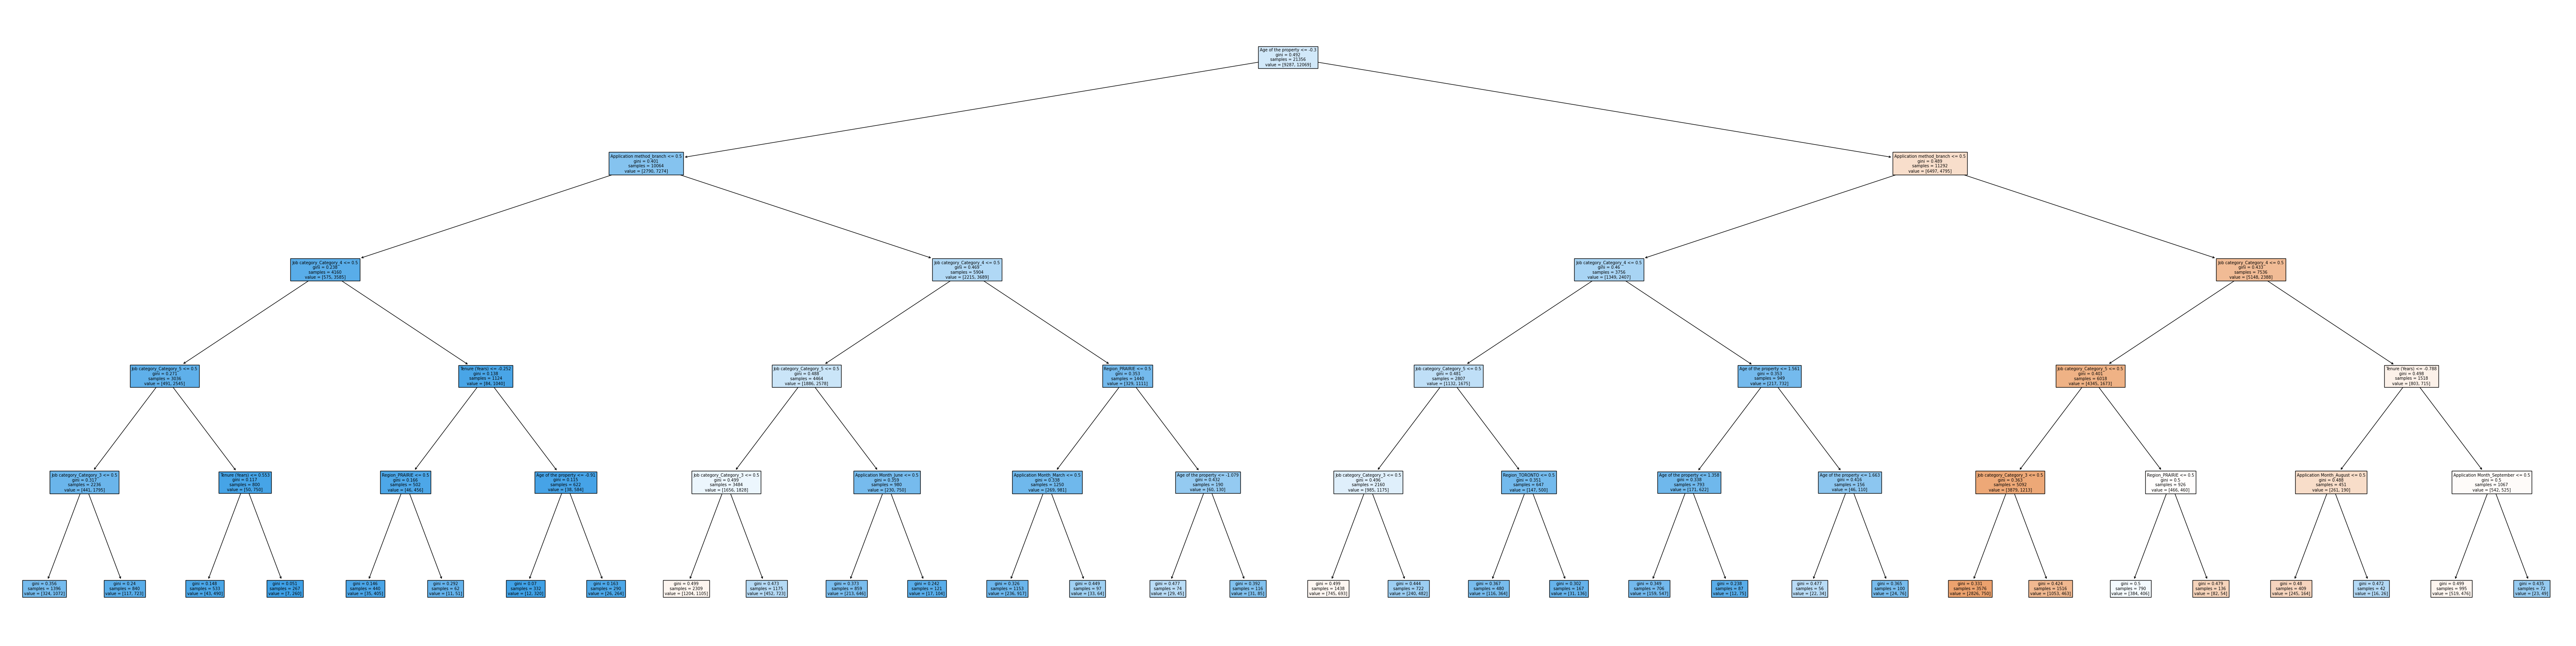

In [38]:
from sklearn.tree import plot_tree, export_text
plt.figure(figsize =(80,20))

plot_tree(grid.best_estimator_, feature_names=X_train.columns, max_depth=5, filled=True)

The features priortised by the decision tree are in the following order - Age of Property -> Application Method -> Job Category and other combinations. Giving Age of property as the most important feature.

Explanation for Improved Operations and Business Processes. <br><br>

The first important factor is Age of property that is used to predict the FTR. We can separate the application files to different review teams based on higher age of property or lower. This could improve the processes and make the process faster.
Application method acts as a second important factor i.e. separating the files coming from Branch and App (web app) will be useful in optimized operations.
To accommodate review of applications by different departments and teams either we can train the existing staff or hire more staff. We can also change the time-shifts of the existing staff in an optimised manner.


____

Other Machine learning models that I tried, but gave similar results:

Logistic Regressor Classifier

In [39]:
# Logistic Regressor Classifier

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0)
clf = clf.fit(X_train, y_train)


acc_log = accuracy_score(y_test, clf.predict(X_test))
print("Accuracy for Logistic Regressor classifier : ",acc_log)

Accuracy for Logistic Regressor classifier :  0.700749063670412


/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



XGBoost Classifier

In [40]:
#XGBoost Classifier

from xgboost import XGBClassifier

bst = XGBClassifier(n_estimators=20, max_depth=10, learning_rate=0.6, objective='binary:logistic', reg_lambda = 10)
bst.fit(X_train, y_train)

acc_xgb = accuracy_score(y_test, bst.predict(X_test))
print("Testing Accuracy for XGBoost classifier : ",acc_xgb)
print("Training accuracy XGB : ",accuracy_score(y_train, bst.predict(X_train)))

Testing Accuracy for XGBoost classifier :  0.6893258426966292
Training accuracy XGB :  0.8106386963850909


Support Vector Classifier

In [41]:
#SVC

from sklearn.svm import SVC

svc = SVC(gamma='auto')
svc.fit(X_train,y_train)

print("Testing accuracy SVC : ",accuracy_score(y_test, svc.predict(X_test)))
print("Training accuracy SVC : ",accuracy_score(y_train, svc.predict(X_train)))

/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Testing accuracy SVC :  0.6943820224719102
Training accuracy SVC :  0.699054129986889


In [42]:
parameters = {'kernel':("linear", "rbf", "poly"), 'C':[0.1, 1, 10, 100]}

grid = GridSearchCV(estimator=svc, param_grid = parameters, cv=5, n_jobs=-1, verbose=True, scoring='accuracy')

grid.fit(X_train,y_train)
print('Best Parameters:', grid.best_params_ , end='\n\n')
print('Best Score:', grid.best_score_ )

print("Testing accuracy SVC after GridsearchCV : ",accuracy_score(y_test, svc.predict(X_test)))
print("Training accuracy SVC after GridsearchCV : ",accuracy_score(y_train, svc.predict(X_train)))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array w

Best Parameters: {'C': 100, 'kernel': 'rbf'}

Best Score: 0.6979770479770808
Testing accuracy SVC after GridsearchCV :  0.6943820224719102
Training accuracy SVC after GridsearchCV :  0.699054129986889


Used Hyperparametric tuning on SVC Classifier, Best Parameters: {'C': 100, 'kernel': 'rbf'}
<br>
Takes some time (3m) to run, expensive.

Naive Bayes

In [43]:
#Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

print("Testing accuracy NaiveBayes : ",accuracy_score(y_test, gnb.predict(X_test)))
print("Training accuracy NaiveBayes : ",accuracy_score(y_train, gnb.predict(X_train)))

Testing accuracy NaiveBayes :  0.6674157303370787
Training accuracy NaiveBayes :  0.6745645251919835


/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Random Forest

In [44]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=5, random_state=0)
rf.fit(X_train,y_train)

print("Testing accuracy RandomForest : ",accuracy_score(y_test, rf.predict(X_test)))
print("Training accuracy RandomForest : ",accuracy_score(y_train, rf.predict(X_train)))

/var/folders/xm/hfw_0r855fs4bwj0bn10_7j80000gn/T/ipykernel_13044/2042126770.py:6: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



Testing accuracy RandomForest :  0.7001872659176029
Training accuracy RandomForest :  0.7051882374976587


Dummy Classifier

In [45]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="uniform")
dummy_clf.fit(X_train,y_train)

print("Testing accuracy DummyClassifier : ",accuracy_score(y_test, dummy_clf.predict(X_test)))
print("Training accuracy DummyClassifier : ",accuracy_score(y_train, dummy_clf.predict(X_train)))

Testing accuracy DummyClassifier :  0.49887640449438203
Training accuracy DummyClassifier :  0.4972841356059187


Neural Network

In [46]:
#Neural Network

from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(alpha=1e-5, hidden_layer_sizes=(32, 32, 8, 4), random_state=1, learning_rate='adaptive', verbose=True)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print("Testing accuracy NN : ",accuracy_score(y_test, y_pred))
print("Training accuracy NN : ",accuracy_score(y_train, clf.predict(X_train)))

/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Iteration 1, loss = 0.67170978
Iteration 2, loss = 0.58795609
Iteration 3, loss = 0.57716643
Iteration 4, loss = 0.57442013
Iteration 5, loss = 0.57284829
Iteration 6, loss = 0.57136328
Iteration 7, loss = 0.57000727
Iteration 8, loss = 0.56897964
Iteration 9, loss = 0.56750531
Iteration 10, loss = 0.56649546
Iteration 11, loss = 0.56539308
Iteration 12, loss = 0.56442169
Iteration 13, loss = 0.56399026
Iteration 14, loss = 0.56342631
Iteration 15, loss = 0.56182073
Iteration 16, loss = 0.56148792
Iteration 17, loss = 0.56071123
Iteration 18, loss = 0.56030320
Iteration 19, loss = 0.55926769
Iteration 20, loss = 0.55908342
Iteration 21, loss = 0.55816706
Iteration 22, loss = 0.55746936
Iteration 23, loss = 0.55797014
Iteration 24, loss = 0.55688347
Iteration 25, loss = 0.55705568
Iteration 26, loss = 0.55623330
Iteration 27, loss = 0.55596296
Iteration 28, loss = 0.55520838
Iteration 29, loss = 0.55572432
Iteration 30, loss = 0.55526264
Iteration 31, loss = 0.55453729
Iteration 32, los

/Users/sneha/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Applying Neural Network model doesn't give a better accuracy than all the other models.

**Thank you**